In [95]:
#create a machine learning model to predict profit based on sales and other features(regression task)
#predict customer type based on their purchasing behavior(classification task)

In [96]:
#step one: import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#import sci-ki learn
#step one: import the necessary libraries
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [97]:
import pandas as pd

# step2 data set
df = pd.read_csv('C:\\Users\\Moi\\Desktop\\megladon\\ecommerce_bigdata.csv')

In [98]:
#show the first 5 rows of the dataset or load t
df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [99]:
#missing values
df.isnull().sum()

TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64

In [100]:
#summary statistics
df.describe()

,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


Text(0, 0.5, 'Profit')

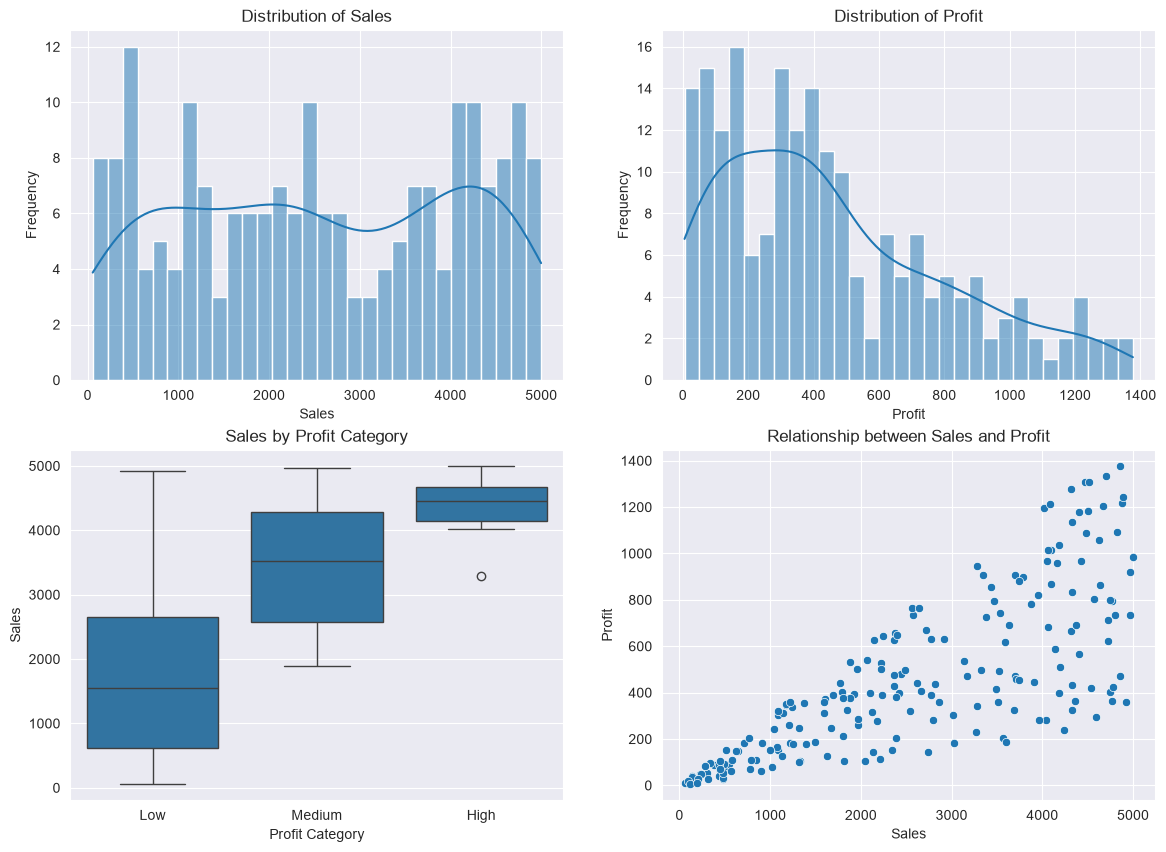

In [101]:
import seaborn as sns

# Data Visualization
# Setup the plotting style
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 Plot Distribution of Sales
sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sales')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

# 2 Plot Distribution of Profit
sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Profit')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')

#exercise;plot sales by profit category(BOX plot)
# Create Profit_Category column
df['Profit_Category'] = pd.cut(df['Profit'], bins=3, labels=['Low', 'Medium', 'High'])

# Now create the boxplot
sns.boxplot(x='Profit_Category', y='Sales', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Sales by Profit Category')
axes[1, 0].set_xlabel('Profit Category')
axes[1, 0].set_ylabel('Sales')

#PLOT RELATIONSHIP BETWEEN SALES AND PROFIT(SCATTER PLOT)
sns.scatterplot(x='Sales', y='Profit', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Relationship between Sales and Profit')
axes[1, 1].set_xlabel('Sales')
axes[1, 1].set_ylabel('Profit')


In [102]:
# Step 4: 3. Feature Engineering: Selecting and creating relevant features that will help the model learn better.
# Create a copy of the original dataframe to avoid modifying it directly
df_processed = df.copy()
# Convert Date to datetime format and extract relevant features (e.g., year, month, day)
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['Weekday'] = df_processed['Date'].dt.weekday

In [103]:
#changing categorical variables to numerical using label encoding
label_encoder = {}
categorical_columns = ['Region', 'ProductCategory', 'CustomerType'] # Replace with your categorical columns
for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col + '_Encoded'] = le.fit_transform(df_processed[col])
    label_encoder[col] = le  # Store the label encoder for future use
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Encoded Region: {'Central': np.int64(0), 'Eastern': np.int64(1), 'Northern': np.int64(2), 'Western': np.int64(3)}
Encoded ProductCategory: {'Beverages': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Food': np.int64(3), 'Household Products': np.int64(4)}
Encoded CustomerType: {'Online': np.int64(0), 'Retail': np.int64(1), 'Wholesale': np.int64(2)}


In [104]:
#convert Date to datetime format

In [105]:
#drop original categorical columns after encoding and transaction  id [not useful for prediction]
# Drop the original categorical columns after encoding and TransactionID (Not useful for prediction)
df_processed.drop(['TransactionID', 'Date', 'Region', 'ProductCategory', 'CustomerType'], axis=1, inplace=True)
print("Processed DataFrame after encoding and dropping unnecessary columns:")
df_processed.head()

Processed DataFrame after encoding and dropping unnecessary columns:


,Sales,Profit,Profit_Category,Month,Day,Weekday,Region_Encoded,ProductCategory_Encoded,CustomerType_Encoded
0,4924,359.44,Low,6,16,1,1,2,2
1,3283,944.32,High,2,12,3,0,2,1
2,4049,967.10,High,3,1,6,2,3,0
3,4331,434.57,Low,6,3,2,3,4,0
4,3283,340.48,Low,1,21,2,3,4,1


In [106]:
# Step 5: Split the dataset into training and testing sets
# Define features and target variable for regression task (predicting profit)
# Regression Task: Predicting Profit based on Sales
print('Regression: Predicting Profit based on Sales')

# Prepare the features (X) and target variable (y) for regression
X_reg = df_processed.drop('Sales', axis=1)  # Features (all columns except 'Profit') Independent variables
y_reg = df_processed['Profit']  # Target variable (Profit) Dependent variable

# Split the dataset into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# What is a random state?
# A random state is a seed value that ensures reproducibility of the results.

print(f'Regression Data Split: ')
print(f"Training set size: {X_train_reg.shape[0]} samples")
print(f"Testing set size: {X_test_reg.shape[0]} samples")

Regression: Predicting Profit based on Sales
Regression Data Split: 
Training set size: 160 samples
Testing set size: 40 samples


In [111]:
from sklearn.tree import DecisionTreeRegressor

# Train multiple regression models and evaluate their performance
# 1. Linear Regression
# 2. Decision Tree Regressor
# 3. Random Forest Regressor

regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

print("\nRegression Model Evaluation:")
regression_results = {}

for name, model in regression_models.items():
    # Train the model
    # Regression Task: Predicting Profit
    X_reg = df_processed.drop(['Profit', 'Profit_Category'], axis=1)
    y_reg = df_processed['Profit']
    
    # Make predictions on the test set
    # Prepare the regression features without the target or Profit_Category
    X_reg = df_processed.drop(['Profit', 'Profit_Category'], axis=1)
    y_reg = df_processed['Profit']
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )

    for name, model in regression_models.items():
        model.fit(X_train_reg, y_train_reg)
        y_pred_reg = model.predict(X_test_reg)
        ...
    y_pred_reg = model.predict(X_test_reg)
    
    # Evaluate the model and calculate RMSE and R-squared
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    regression_results[name] = {'RMSE': rmse, 'R-squared': r2}
    
    print(f"{name}: RMSE = {rmse:.4f}, R-squared = {r2:.4f}")

    # Store results 
    regression_results[name] = {
        'model': model,
        'RMSE': rmse,
        'mse': mean_squared_error(y_test_reg, y_pred_reg),
        'R-squared': r2,
        'predicted_profit': y_pred_reg
    }

    print(f"{name} model trained and evaluated successfully.")
    print(f"Mean Squared Error (MSE): {regression_results[name]['mse']:.2f}")
    print(f"Root Mean Squared Error (RMSE): {regression_results[name]['RMSE']:.4f}")
    print(f"R-squared: {regression_results[name]['R-squared']:.4f}")
    print(f"Interpretation: {regression_results[name]['predicted_profit'][:5]}")  # Display first 5 predictions


Regression Model Evaluation:
Random Forest Regressor: RMSE = 218.0138, R-squared = 0.5793
Random Forest Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 47530.02
Root Mean Squared Error (RMSE): 218.0138
R-squared: 0.5793
Interpretation: [ 68.1485 462.9027 554.7863 787.9254 917.2376]
Random Forest Regressor: RMSE = 218.0138, R-squared = 0.5793
Random Forest Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 47530.02
Root Mean Squared Error (RMSE): 218.0138
R-squared: 0.5793
Interpretation: [ 68.1485 462.9027 554.7863 787.9254 917.2376]
Random Forest Regressor: RMSE = 218.0138, R-squared = 0.5793
Random Forest Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 47530.02
Root Mean Squared Error (RMSE): 218.0138
R-squared: 0.5793
Interpretation: [ 68.1485 462.9027 554.7863 787.9254 917.2376]


In [ ]:
#assignment do classification task: predicting customer type based on transaction data
